In [ ]:
# CCS 3209: Simulation and Modelling
## Week 2 Laboratory Work
### Simulation Designs, Model Verification and Validation

# Part B: Implementation and Verification

## Task B1: Deterministic Model Implementation

The deterministic model is implemented using the specifications established in Part A. The model contains one consultation officer, patients arriving every 5 minutes, and a fixed consultation time of 3 minutes.

An event trace is recorded for each patient to support verification against the manual calculations.

In [12]:
# Task B1: Deterministic Model Parameters

NUM_PATIENTS = 6
INTERARRIVAL_TIME = 5
SERVICE_TIME = 3
SERVER_CAPACITY = 1

print("Number of patients:", NUM_PATIENTS)
print("Interarrival time:", INTERARRIVAL_TIME, "minutes")
print("Service time:", SERVICE_TIME, "minutes")
print("Server capacity:", SERVER_CAPACITY)

Number of patients: 6
Interarrival time: 5 minutes
Service time: 3 minutes
Server capacity: 1


In [13]:
# Task B1: Deterministic Model and Event Trace

patients = []
event_trace = []

previous_departure = 0

for patient_id in range(1, NUM_PATIENTS + 1):

    arrival_time = (patient_id - 1) * INTERARRIVAL_TIME
    service_start = max(arrival_time, previous_departure)
    waiting_time = service_start - arrival_time
    departure_time = service_start + SERVICE_TIME

    # Queue length at arrival
    if arrival_time < previous_departure:
        queue_length = 1
    else:
        queue_length = 0

    # Store patient results
    patients.append({
        "Patient ID": patient_id,
        "Arrival": arrival_time,
        "Service Start": service_start,
        "Departure": departure_time,
        "Waiting Time": waiting_time
    })

    # Event 1: Arrival
    event_trace.append({
        "Patient ID": patient_id,
        "Event Time": arrival_time,
        "Event Type": "Arrival",
        "Queue Length": queue_length,
        "Server State": "Busy" if arrival_time == service_start else "Busy",
        "Service Start": service_start,
        "Departure": departure_time,
        "Waiting Time": waiting_time
    })

    # Event 2: Service Start
    event_trace.append({
        "Patient ID": patient_id,
        "Event Time": service_start,
        "Event Type": "Service Start",
        "Queue Length": 0,
        "Server State": "Busy",
        "Service Start": service_start,
        "Departure": departure_time,
        "Waiting Time": waiting_time
    })

    # Event 3: Departure
    event_trace.append({
        "Patient ID": patient_id,
        "Event Time": departure_time,
        "Event Type": "Departure",
        "Queue Length": 0,
        "Server State": "Idle",
        "Service Start": service_start,
        "Departure": departure_time,
        "Waiting Time": waiting_time
    })

    previous_departure = departure_time

In [14]:
# Display the deterministic results

print("Patient | Arrival | Service Start | Departure | Waiting Time")
print("-" * 62)

for patient in patients:
    print(
        f"P{patient['Patient ID']}      | "
        f"{patient['Arrival']:7} | "
        f"{patient['Service Start']:13} | "
        f"{patient['Departure']:9} | "
        f"{patient['Waiting Time']:12}"
    )

Patient | Arrival | Service Start | Departure | Waiting Time
--------------------------------------------------------------
P1      |       0 |             0 |         3 |            0
P2      |       5 |             5 |         8 |            0
P3      |      10 |            10 |        13 |            0
P4      |      15 |            15 |        18 |            0
P5      |      20 |            20 |        23 |            0
P6      |      25 |            25 |        28 |            0


In [15]:
# Calculate mean waiting time

total_waiting_time = sum(patient["Waiting Time"] for patient in patients)
mean_waiting_time = total_waiting_time / len(patients)

print("Mean waiting time:", mean_waiting_time, "minutes")

Mean waiting time: 0.0 minutes


## Task B2: Desk Check and Event Trace

In [20]:
# Display the event trace in an aligned table

print(
    f"{'Patient':<10}"
    f"{'Event Time':<12}"
    f"{'Event Type':<17}"
    f"{'Queue Length':<15}"
    f"{'Server State':<15}"
    f"{'Service Start':<16}"
    f"{'Departure':<13}"
    f"{'Waiting Time':<13}"
)

print("-" * 111)

for event in event_trace:
    print(
        f"{'P' + str(event['Patient ID']):<10}"
        f"{event['Event Time']:<12}"
        f"{event['Event Type']:<17}"
        f"{event['Queue Length']:<15}"
        f"{event['Server State']:<15}"
        f"{event['Service Start']:<16}"
        f"{event['Departure']:<13}"
        f"{event['Waiting Time']:<13}"
    )

Patient   Event Time  Event Type       Queue Length   Server State   Service Start   Departure    Waiting Time 
---------------------------------------------------------------------------------------------------------------
P1        0           Arrival          0              Busy           0               3            0            
P1        0           Service Start    0              Busy           0               3            0            
P1        3           Departure        0              Idle           0               3            0            
P2        5           Arrival          0              Busy           5               8            0            
P2        5           Service Start    0              Busy           5               8            0            
P2        8           Departure        0              Idle           5               8            0            
P3        10          Arrival          0              Busy           10              13           0     

## Task B3: Assertions and Extreme-Condition Tests

**Purpose:**
Assertions check that the model's internal logic never violates a rule that should always hold, regardless of the input.
Extreme-condition tests check that the model behaves *sensibly* — in the right direction — when inputs are pushed to unusual or boundary values, even if the exact numbers aren't known in advance.

In [21]:
# B3: Programmed Assertions

def check_assertions(patients, queue_lengths, server_capacity):

    # 1. Queue length cannot be negative
    for queue_length in queue_lengths:
        assert queue_length >= 0, \
            "Queue length cannot be negative."

    # 2. Busy servers cannot exceed available capacity
    assert server_capacity >= 1, \
        "Server capacity must be at least 1."

    # 3, 4 and 5: Patient-level checks
    for patient in patients:

        assert patient["Departure"] >= patient["Arrival"], \
            "Departure cannot occur before arrival."

        assert patient["Service Start"] >= patient["Arrival"], \
            "Service cannot start before arrival."

        assert patient["Waiting Time"] >= 0, \
            "Waiting time cannot be negative."

    print("All programmed assertions passed.")

In [22]:
# B3: Simple Verification Simulation

def simulate_queue(arrival_times, service_time, server_capacity=1):

    patients = []
    server_available = [0] * server_capacity

    for patient_id, arrival_time in enumerate(arrival_times, start=1):

        # Find the server that becomes available first
        server_index = min(
            range(server_capacity),
            key=lambda i: server_available[i]
        )

        service_start = max(
            arrival_time,
            server_available[server_index]
        )

        waiting_time = service_start - arrival_time
        departure_time = service_start + service_time

        patients.append({
            "Patient ID": patient_id,
            "Arrival": arrival_time,
            "Service Start": service_start,
            "Departure": departure_time,
            "Waiting Time": waiting_time
        })

        server_available[server_index] = departure_time

    return patients

In [23]:
# B3 Test 1: Zero Arrivals

arrival_times = []

patients_test1 = simulate_queue(
    arrival_times,
    service_time=3,
    server_capacity=1
)

assert len(patients_test1) == 0, \
    "Zero arrivals should result in zero served patients."

print("Test 1 passed: Zero arrivals produce zero served patients.")

Test 1 passed: Zero arrivals produce zero served patients.


In [24]:
# B3 Test 2: Deterministic No-Waiting Case

arrival_times = [0, 5, 10, 15, 20, 25]

patients_test2 = simulate_queue(
    arrival_times,
    service_time=3,
    server_capacity=1
)

assert all(
    patient["Waiting Time"] == 0
    for patient in patients_test2
), "No patient should experience waiting."

print("Test 2 passed: No waiting occurs in the deterministic case.")

Test 2 passed: No waiting occurs in the deterministic case.


In [25]:
# B3 Test 3: Congestion Case

arrival_times = [0, 1, 2, 3, 4, 5]

patients_test3 = simulate_queue(
    arrival_times,
    service_time=5,
    server_capacity=1
)

waiting_times = [
    patient["Waiting Time"]
    for patient in patients_test3
]

assert any(
    waiting_time > 0
    for waiting_time in waiting_times
), "Congestion should produce waiting."

print("Test 3 passed: Congestion produces waiting.")
print("Waiting times:", waiting_times)

Test 3 passed: Congestion produces waiting.
Waiting times: [0, 4, 8, 12, 16, 20]


In [26]:
# B3 Test 4: Very Large Resource Capacity

arrival_times = [0, 1, 2, 3, 4, 5]

patients_test4 = simulate_queue(
    arrival_times,
    service_time=5,
    server_capacity=10
)

waiting_times = [
    patient["Waiting Time"]
    for patient in patients_test4
]

assert all(
    waiting_time == 0
    for waiting_time in waiting_times
), "Very large capacity should eliminate waiting in this test."

print("Test 4 passed: Very large resource capacity eliminates waiting.")
print("Waiting times:", waiting_times)

Test 4 passed: Very large resource capacity eliminates waiting.
Waiting times: [0, 0, 0, 0, 0, 0]


In [27]:
# B3: Apply Assertions to the B1 Model

queue_lengths = [
    event["Queue Length"]
    for event in event_trace
]

check_assertions(
    patients,
    queue_lengths,
    SERVER_CAPACITY
)

All programmed assertions passed.


# PART C: STOCHASTIC MODEL AND VALIDATION

The model will use:
- **Arrival times:** Exponentially distributed interarrival times with a mean of 5 minutes.
- **Service times:** Triangular distribution with a minimum of 2 minutes, a mode of 4 minutes, and a maximum of 8 minutes.
- **Operating period:** 8 hours (480 minutes).
- **Independent replications:** 20 simulation runs.

# Task C1:Introducing randomness and running 20 independent replications.

In [29]:
import numpy as np
import csv

RUN_LENGTH = 480
MEAN_INTERARRIVAL = 5
SERVICE_MIN = 2
SERVICE_MODE = 4
SERVICE_MAX = 8
NUM_REPLICATIONS = 20
SERVER_CAPACITY = 1

print("Simulation parameters defined successfully.")

Simulation parameters defined successfully.


In [30]:

def generate_arrivals(run_length=RUN_LENGTH):
    """
    Generate patient arrival times using exponential interarrival times.
    """
    arrival_times = []
    current_time = 0

    while True:
        interarrival_time = np.random.exponential(
            scale=MEAN_INTERARRIVAL
        )

        current_time += interarrival_time

        if current_time > run_length:
            break

        arrival_times.append(current_time)

    return arrival_times


# Demonstrate arrival generation
np.random.seed(42)
sample_arrivals = generate_arrivals()

print("Number of arrivals:", len(sample_arrivals))
print("First five arrival times:", sample_arrivals[:5])

Number of arrivals: 105
First five arrival times: [2.3463404498842957, 17.3969476044719, 23.98067607219915, 28.545388841078914, 29.393513193390646]


In [31]:
def generate_service_times(num_patients):
    """
    Generate consultation times using a triangular distribution
    (minimum 2, mode 4, maximum 8 minutes).
    """
    return np.random.triangular(SERVICE_MIN, SERVICE_MODE, SERVICE_MAX, size=num_patients)

sample_service_times = generate_service_times(len(sample_arrivals))
print("Number of service times generated:", len(sample_service_times))
print("First five service times:", np.round(sample_service_times[:5], 2))

Number of service times generated: 105
First five service times: [4.24 5.58 3.66 2.96 3.86]


In [32]:
def simulate_single_day(arrival_times, service_times, run_length=RUN_LENGTH,
                         server_capacity=SERVER_CAPACITY):
    """
    Process patients through the queue by assigning each arrival to whichever
    server becomes free soonest. Returns per-patient records and day-level
    summary statistics.
    """
    server_free_time = np.zeros(server_capacity)
    records = []

    for arrival, service_time in zip(arrival_times, service_times):
        server_index = int(np.argmin(server_free_time))
        service_start = max(arrival, server_free_time[server_index])
        departure = service_start + service_time
        waiting_time = service_start - arrival
        records.append((arrival, service_start, departure, service_time, waiting_time))
        server_free_time[server_index] = departure

    waits = [r[4] for r in records]

    # Queue length over time: +1 at arrival, -1 when service starts
    events = []
    for arrival, service_start, _, _, _ in records:
        events.append((arrival, 1))
        events.append((service_start, -1))
    events.sort()
    running, max_queue_length = 0, 0
    for _, delta in events:
        running += delta
        max_queue_length = max(max_queue_length, running)

    # Utilization: busy time clipped to [0, run_length]
    busy_time = sum(max(0.0, min(dep, run_length) - start) for _, start, dep, _, _ in records)
    utilization = (busy_time / (run_length * server_capacity)) * 100

    summary = {
        "mean_waiting_time": (sum(waits) / len(waits)) if waits else 0,
        "max_queue_length": max_queue_length,
        "throughput": len(records),
        "utilization": utilization
    }
    return records, summary

sample_records, sample_summary = simulate_single_day(sample_arrivals, sample_service_times)
print("Sample day summary:", sample_summary)

Sample day summary: {'mean_waiting_time': np.float64(18.29572473801212), 'max_queue_length': 11, 'throughput': 105, 'utilization': np.float64(94.76658975375561)}


In [33]:
np.random.seed(42)  # fixed seed so results are reproducible

replication_results = []
for rep in range(1, NUM_REPLICATIONS + 1):
    arrivals = generate_arrivals()
    service_times = generate_service_times(len(arrivals))
    _, summary = simulate_single_day(arrivals, service_times)
    summary["Replication"] = rep
    replication_results.append(summary)

with open("stochastic_baseline_20reps.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["Replication", "mean_waiting_time",
                                            "max_queue_length", "throughput", "utilization"])
    writer.writeheader()
    for row in replication_results:
        writer.writerow(row)

for r in replication_results:
    print(f"Rep {r['Replication']:2d}: wait={r['mean_waiting_time']:6.2f}  "
          f"max_q={r['max_queue_length']:3d}  throughput={r['throughput']:3d}  "
          f"util={r['utilization']:6.2f}%")

Rep  1: wait= 18.30  max_q= 11  throughput=105  util= 94.77%
Rep  2: wait=  5.26  max_q=  5  throughput= 88  util= 76.48%
Rep  3: wait= 13.69  max_q=  8  throughput= 84  util= 87.56%
Rep  4: wait= 64.55  max_q= 29  throughput=121  util= 94.86%
Rep  5: wait= 23.47  max_q= 15  throughput=110  util= 90.95%
Rep  6: wait= 11.89  max_q=  7  throughput= 81  util= 80.32%
Rep  7: wait= 12.53  max_q= 11  throughput= 93  util= 82.96%
Rep  8: wait=  8.27  max_q=  6  throughput= 93  util= 89.49%
Rep  9: wait= 13.36  max_q=  8  throughput= 97  util= 90.83%
Rep 10: wait= 14.34  max_q=  8  throughput= 96  util= 93.45%
Rep 11: wait= 24.24  max_q= 12  throughput=102  util= 94.10%
Rep 12: wait=  9.92  max_q=  7  throughput= 93  util= 86.92%
Rep 13: wait= 31.51  max_q= 15  throughput=104  util= 96.94%
Rep 14: wait= 15.28  max_q= 10  throughput=105  util= 95.77%
Rep 15: wait= 10.13  max_q=  8  throughput= 84  util= 79.05%
Rep 16: wait=  4.84  max_q=  5  throughput= 87  util= 79.86%
Rep 17: wait= 13.33  max

# Task C2: Reference Observations

**Purpose:** before the simulated model can be judged valid, we need a real-system baseline to compare it against. This cell simply records the reference dataset given in the lab (10 observed operating days) and computes the observed mean for each performance measure, so Task C3 can compare the model's simulated output against real numbers rather than assumptions.

In [34]:
# Task C2: Reference observations (given reference dataset)
observed_data = [
    {"Day": 1,  "Mean Waiting": 7.8, "Max Queue": 5, "Utilization": 76},
    {"Day": 2,  "Mean Waiting": 8.6, "Max Queue": 6, "Utilization": 79},
    {"Day": 3,  "Mean Waiting": 7.4, "Max Queue": 5, "Utilization": 75},
    {"Day": 4,  "Mean Waiting": 9.1, "Max Queue": 7, "Utilization": 82},
    {"Day": 5,  "Mean Waiting": 8.2, "Max Queue": 6, "Utilization": 78},
    {"Day": 6,  "Mean Waiting": 7.9, "Max Queue": 5, "Utilization": 77},
    {"Day": 7,  "Mean Waiting": 8.8, "Max Queue": 6, "Utilization": 81},
    {"Day": 8,  "Mean Waiting": 8.0, "Max Queue": 5, "Utilization": 77},
    {"Day": 9,  "Mean Waiting": 8.5, "Max Queue": 6, "Utilization": 80},
    {"Day": 10, "Mean Waiting": 7.7, "Max Queue": 5, "Utilization": 76},
]

observed_mean_waiting = sum(d["Mean Waiting"] for d in observed_data) / len(observed_data)
observed_mean_max_queue = sum(d["Max Queue"] for d in observed_data) / len(observed_data)
observed_mean_utilization = sum(d["Utilization"] for d in observed_data) / len(observed_data)

print("Observed mean waiting time:", round(observed_mean_waiting, 2), "minutes")
print("Observed mean max queue:", round(observed_mean_max_queue, 2))
print("Observed mean utilization:", round(observed_mean_utilization, 2), "%")

Observed mean waiting time: 8.2 minutes
Observed mean max queue: 5.6
Observed mean utilization: 78.1 %


## Task C3: Validation Comparison

**Purpose:** this is the core validation step — comparing the stochastic model's output
(Task C1) against the real-system reference data (Task C2) to determine whether the model
is an adequate representation of the actual outpatient queue, not just a correctly
implemented program (which Part B already established).

In [35]:
# Step 1: Observed mean for each performance measure (from Task C2's reference data)
observed_mean_waiting = sum(d["Mean Waiting"] for d in observed_data) / len(observed_data)
observed_mean_max_queue = sum(d["Max Queue"] for d in observed_data) / len(observed_data)
observed_mean_utilization = sum(d["Utilization"] for d in observed_data) / len(observed_data)

print("Observed mean waiting time:", round(observed_mean_waiting, 2), "minutes")
print("Observed mean max queue:", round(observed_mean_max_queue, 2))
print("Observed mean utilization:", round(observed_mean_utilization, 2), "%")

Observed mean waiting time: 8.2 minutes
Observed mean max queue: 5.6
Observed mean utilization: 78.1 %


In [36]:
import math

def calculate_mean(values):
    return sum(values) / len(values)

def calculate_standard_deviation(values):
    sample_mean = calculate_mean(values)
    squared_differences = [(value - sample_mean) ** 2 for value in values]
    return (sum(squared_differences) / (len(values) - 1)) ** 0.5

def summarize_replications(measure_name):
    """Returns (mean, ci_lower, ci_upper) for a performance measure across the 20 replications."""
    values_across_replications = [replication[measure_name] for replication in replication_results]
    sample_mean = calculate_mean(values_across_replications)
    sample_standard_deviation = calculate_standard_deviation(values_across_replications)
    number_of_replications = len(values_across_replications)
    margin_of_error = 1.96 * sample_standard_deviation / math.sqrt(number_of_replications)
    return sample_mean, sample_mean - margin_of_error, sample_mean + margin_of_error

simulated_mean_waiting_time, waiting_time_ci_lower, waiting_time_ci_upper = \
    summarize_replications("mean_waiting_time")
simulated_mean_max_queue, max_queue_ci_lower, max_queue_ci_upper = \
    summarize_replications("max_queue_length")
simulated_mean_utilization, utilization_ci_lower, utilization_ci_upper = \
    summarize_replications("utilization")

print(f"Simulated mean waiting time: {simulated_mean_waiting_time:.2f} min  "
      f"95% CI: [{waiting_time_ci_lower:.2f}, {waiting_time_ci_upper:.2f}]")
print(f"Simulated mean max queue: {simulated_mean_max_queue:.2f}  "
      f"95% CI: [{max_queue_ci_lower:.2f}, {max_queue_ci_upper:.2f}]")
print(f"Simulated mean utilization: {simulated_mean_utilization:.2f}%  "
      f"95% CI: [{utilization_ci_lower:.2f}, {utilization_ci_upper:.2f}]")

Simulated mean waiting time: 17.38 min  95% CI: [11.66, 23.10]
Simulated mean max queue: 10.40  95% CI: [8.07, 12.73]
Simulated mean utilization: 88.56%  95% CI: [85.79, 91.32]


In [37]:
acceptance_tolerance_percent = 10

percentage_error_waiting_time = (
    (simulated_mean_waiting_time - observed_mean_waiting) / observed_mean_waiting * 100
)
percentage_error_utilization = (
    (simulated_mean_utilization - observed_mean_utilization) / observed_mean_utilization * 100
)

waiting_time_passes_acceptance = abs(percentage_error_waiting_time) <= acceptance_tolerance_percent
utilization_passes_acceptance = abs(percentage_error_utilization) <= acceptance_tolerance_percent

print(f"Percentage error — waiting time: {percentage_error_waiting_time:+.1f}%  "
      f"(within ±{acceptance_tolerance_percent}%? {waiting_time_passes_acceptance})")
print(f"Percentage error — utilization: {percentage_error_utilization:+.1f}%  "
      f"(within ±{acceptance_tolerance_percent}%? {utilization_passes_acceptance})")

Percentage error — waiting time: +111.9%  (within ±10%? False)
Percentage error — utilization: +13.4%  (within ±10%? False)


In [38]:
comparison_table_rows = [
    {
        "Measure": "Mean waiting time (min)",
        "Observed Mean": round(observed_mean_waiting, 2),
        "Simulated Mean": round(simulated_mean_waiting_time, 2),
        "95% Confidence Interval": f"[{waiting_time_ci_lower:.2f}, {waiting_time_ci_upper:.2f}]",
        "Percentage Error": f"{percentage_error_waiting_time:+.1f}%",
        "Within ±10%?": "Yes" if waiting_time_passes_acceptance else "No"
    },
    {
        "Measure": "Maximum queue length",
        "Observed Mean": round(observed_mean_max_queue, 2),
        "Simulated Mean": round(simulated_mean_max_queue, 2),
        "95% Confidence Interval": f"[{max_queue_ci_lower:.2f}, {max_queue_ci_upper:.2f}]",
        "Percentage Error": "Not required",
        "Within ±10%?": "Not required"
    },
    {
        "Measure": "Utilization (%)",
        "Observed Mean": round(observed_mean_utilization, 2),
        "Simulated Mean": round(simulated_mean_utilization, 2),
        "95% Confidence Interval": f"[{utilization_ci_lower:.2f}, {utilization_ci_upper:.2f}]",
        "Percentage Error": f"{percentage_error_utilization:+.1f}%",
        "Within ±10%?": "Yes" if utilization_passes_acceptance else "No"
    },
]

column_names = list(comparison_table_rows[0].keys())
column_widths = {name: max(len(name), max(len(str(row[name])) for row in comparison_table_rows)) + 2
                  for name in column_names}
header_line = "".join(name.ljust(column_widths[name]) for name in column_names)
print(header_line)
print("-" * len(header_line))
for row in comparison_table_rows:
    print("".join(str(row[name]).ljust(column_widths[name]) for name in column_names))

Measure                  Observed Mean  Simulated Mean  95% Confidence Interval  Percentage Error  Within ±10%?  
-----------------------------------------------------------------------------------------------------------------
Mean waiting time (min)  8.2            17.38           [11.66, 23.10]           +111.9%           No            
Maximum queue length     5.6            10.4            [8.07, 12.73]            Not required      Not required  
Utilization (%)          78.1           88.56           [85.79, 91.32]           +13.4%            No            


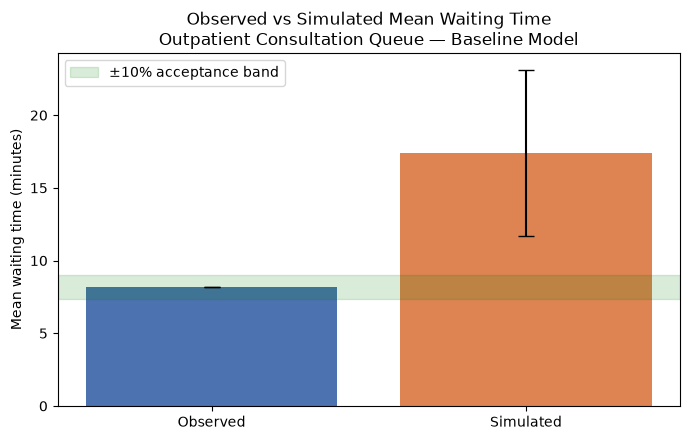

In [41]:
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(7, 4.5))
categories = ["Observed", "Simulated"]
mean_waiting_values = [observed_mean_waiting, simulated_mean_waiting_time]
error_bar_heights = [
    [0, simulated_mean_waiting_time - waiting_time_ci_lower],   # lower errors
    [0, waiting_time_ci_upper - simulated_mean_waiting_time]     # upper errors
]

axis.bar(categories, mean_waiting_values, yerr=error_bar_heights, capsize=6,
         color=["#4C72B0", "#DD8452"])
axis.set_ylabel("Mean waiting time (minutes)")
axis.set_title("Observed vs Simulated Mean Waiting Time\nOutpatient Consultation Queue — Baseline Model")

acceptance_band_lower = observed_mean_waiting * 0.9
acceptance_band_upper = observed_mean_waiting * 1.1
axis.axhspan(acceptance_band_lower, acceptance_band_upper, color="green", alpha=0.15,
             label="±10% acceptance band")
axis.legend(loc="upper left")
plt.tight_layout()
plt.savefig("observed_vs_simulated_waiting_time.png", dpi=110)
plt.show()

# Part D: Calibration and Revalidation

## D3: Revalidation After Calibration

The model was calibrated by adjusting the service-time distribution based on the
observed utilization and congestion. The service-time mode was reduced from
4 minutes to 3 minutes, while the maximum service time was reduced from
8 minutes to 6 minutes. The minimum service time remained at 2 minutes.

The calibrated model is revalidated using 20 independent replications,
maintaining the same arrival process, simulation run length, server capacity,
and performance measures used in Part C.

The results will be compared with the observed values and the original
uncalibrated model to determine whether the calibration improved agreement.

In [85]:
# D3: Calibrated simulation parameters

CAL_RUN_LENGTH = 480
CAL_MEAN_INTERARRIVAL = 5
CAL_SERVICE_MIN = 2
CAL_SERVICE_MODE = 3
CAL_SERVICE_MAX = 6
CAL_NUM_REPLICATIONS = 20
CAL_SERVER_CAPACITY = 1

print("Calibrated parameters defined successfully.")

Calibrated parameters defined successfully.


In [86]:
def generate_calibrated_arrivals(run_length=CAL_RUN_LENGTH):
    """
    Generate patient arrival times using the same exponential
    interarrival-time assumption used in Part C.
    """
    arrival_times = []
    current_time = 0

    while True:
        interarrival_time = np.random.exponential(
            scale=CAL_MEAN_INTERARRIVAL
        )

        current_time += interarrival_time

        if current_time > run_length:
            break

        arrival_times.append(current_time)

    return arrival_times

In [87]:
def generate_calibrated_service_times(num_patients):
    """
    Generate consultation times using the calibrated triangular
    distribution (minimum 2, mode 3, maximum 6 minutes).
    """
    return np.random.triangular(
        CAL_SERVICE_MIN,
        CAL_SERVICE_MODE,
        CAL_SERVICE_MAX,
        size=num_patients
    )

In [88]:
def simulate_calibrated_day(
    arrival_times,
    service_times,
    run_length=CAL_RUN_LENGTH,
    server_capacity=CAL_SERVER_CAPACITY
):
    """
    Process patients through the calibrated queue model and
    return per-patient records and day-level summary statistics.
    """
    server_free_time = np.zeros(server_capacity)
    records = []

    for arrival, service_time in zip(arrival_times, service_times):
        server_index = int(np.argmin(server_free_time))

        service_start = max(
            arrival,
            server_free_time[server_index]
        )

        departure = service_start + service_time
        waiting_time = service_start - arrival

        records.append(
            (
                arrival,
                service_start,
                departure,
                service_time,
                waiting_time
            )
        )

        server_free_time[server_index] = departure

    waits = [r[4] for r in records]

    # Queue length over time
    events = []

    for arrival, service_start, _, _, _ in records:
        events.append((arrival, 1))
        events.append((service_start, -1))

    events.sort()

    running = 0
    max_queue_length = 0

    for _, delta in events:
        running += delta
        max_queue_length = max(max_queue_length, running)

    # Utilization
    busy_time = sum(
        max(0.0, min(dep, run_length) - start)
        for _, start, dep, _, _ in records
    )

    utilization = (
        busy_time / (run_length * server_capacity)
    ) * 100

    summary = {
        "mean_waiting_time": (
            sum(waits) / len(waits)
            if waits else 0
        ),
        "max_queue_length": max_queue_length,
        "throughput": len(records),
        "utilization": utilization
    }

    return records, summary

In [89]:
# D3: Run 20 calibrated replications

np.random.seed(42)

calibrated_results = []

for rep in range(1, CAL_NUM_REPLICATIONS + 1):

    arrivals = generate_calibrated_arrivals()

    service_times = generate_calibrated_service_times(
        len(arrivals)
    )

    _, summary = simulate_calibrated_day(
        arrivals,
        service_times
    )

    summary["Replication"] = rep
    calibrated_results.append(summary)

print("Calibrated replications completed:", len(calibrated_results))

Calibrated replications completed: 20


In [90]:
# Display calibrated replication results

for r in calibrated_results:
    print(
        f"Rep {r['Replication']:2d}: "
        f"wait={r['mean_waiting_time']:6.2f}  "
        f"max_q={r['max_queue_length']:3d}  "
        f"throughput={r['throughput']:3d}  "
        f"util={r['utilization']:6.2f}%"
    )

Rep  1: wait=  6.07  max_q=  7  throughput=105  util= 78.60%
Rep  2: wait=  2.35  max_q=  4  throughput= 88  util= 62.57%
Rep  3: wait=  4.65  max_q=  5  throughput= 84  util= 68.55%
Rep  4: wait= 24.10  max_q= 13  throughput=121  util= 90.07%
Rep  5: wait=  7.03  max_q=  7  throughput=110  util= 79.43%
Rep  6: wait=  4.48  max_q=  6  throughput= 81  util= 64.49%
Rep  7: wait=  5.81  max_q=  7  throughput= 93  util= 69.79%
Rep  8: wait=  2.65  max_q=  3  throughput= 93  util= 70.35%
Rep  9: wait=  4.20  max_q=  5  throughput= 97  util= 71.98%
Rep 10: wait=  3.24  max_q=  4  throughput= 96  util= 74.06%
Rep 11: wait=  5.02  max_q=  5  throughput=102  util= 78.89%
Rep 12: wait=  3.81  max_q=  5  throughput= 93  util= 68.72%
Rep 13: wait=  6.70  max_q=  6  throughput=104  util= 80.96%
Rep 14: wait=  4.98  max_q=  6  throughput=105  util= 76.91%
Rep 15: wait=  3.33  max_q=  4  throughput= 84  util= 63.25%
Rep 16: wait=  2.01  max_q=  3  throughput= 87  util= 63.66%
Rep 17: wait=  3.91  max

In [91]:
# Save calibrated results

with open(
    "stochastic_calibrated_20reps.csv",
    "w",
    newline=""
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=[
            "Replication",
            "mean_waiting_time",
            "max_queue_length",
            "throughput",
            "utilization"
        ]
    )

    writer.writeheader()

    for row in calibrated_results:
        writer.writerow(row)

print("Calibrated results saved successfully.")

Calibrated results saved successfully.


In [92]:
# D3: Calculate calibrated means and 95% confidence intervals

def calculate_ci(values):
    values = np.array(values)
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    margin = 1.96 * std / np.sqrt(len(values))
    return mean, mean - margin, mean + margin


cal_wait = [
    r["mean_waiting_time"]
    for r in calibrated_results
]

cal_queue = [
    r["max_queue_length"]
    for r in calibrated_results
]

cal_throughput = [
    r["throughput"]
    for r in calibrated_results
]

cal_utilization = [
    r["utilization"]
    for r in calibrated_results
]

calibrated_ci = {
    "Mean waiting time": calculate_ci(cal_wait),
    "Maximum queue length": calculate_ci(cal_queue),
    "Throughput": calculate_ci(cal_throughput),
    "Utilization": calculate_ci(cal_utilization)
}

print("Calibrated model summary:")
print("-" * 65)

for measure, (mean, lower, upper) in calibrated_ci.items():
    print(
        f"{measure:<25} "
        f"Mean = {mean:.2f}, "
        f"95% CI = ({lower:.2f}, {upper:.2f})"
    )

Calibrated model summary:
-----------------------------------------------------------------
Mean waiting time         Mean = 5.55, 95% CI = (3.53, 7.58)
Maximum queue length      Mean = 5.60, 95% CI = (4.66, 6.54)
Throughput                Mean = 96.40, 95% CI = (92.08, 100.72)
Utilization               Mean = 72.48, 95% CI = (69.40, 75.55)


In [93]:
# D3: Calibrated model results table

print("D3: Calibrated Model Results")
print("=" * 75)
print(
    f"{'Measure':<25}"
    f"{'Mean':>12}"
    f"{'95% CI Lower':>18}"
    f"{'95% CI Upper':>18}"
)
print("-" * 75)

for measure, (mean, lower, upper) in calibrated_ci.items():
    print(
        f"{measure:<25}"
        f"{mean:>12.2f}"
        f"{lower:>18.2f}"
        f"{upper:>18.2f}"
    )

D3: Calibrated Model Results
Measure                          Mean      95% CI Lower      95% CI Upper
---------------------------------------------------------------------------
Mean waiting time                5.55              3.53              7.58
Maximum queue length             5.60              4.66              6.54
Throughput                      96.40             92.08            100.72
Utilization                     72.48             69.40             75.55


In [94]:
# D3: Compare original and calibrated models

# Original Part C results
original_wait = np.array([
    r["mean_waiting_time"] for r in replication_results
])

original_queue = np.array([
    r["max_queue_length"] for r in replication_results
])

original_throughput = np.array([
    r["throughput"] for r in replication_results
])

original_utilization = np.array([
    r["utilization"] for r in replication_results
])

# Calculate original model confidence intervals
original_ci = {
    "Mean waiting time": calculate_ci(original_wait),
    "Maximum queue length": calculate_ci(original_queue),
    "Throughput": calculate_ci(original_throughput),
    "Utilization": calculate_ci(original_utilization)
}

# Display comparison
print("D3: Before vs After Calibration")
print("=" * 90)

print(
    f"{'Measure':<25}"
    f"{'Original Mean':>18}"
    f"{'Calibrated Mean':>20}"
    f"{'Change':>15}"
)
print("-" * 90)

for measure in original_ci:

    original_mean = original_ci[measure][0]
    calibrated_mean = calibrated_ci[measure][0]
    change = calibrated_mean - original_mean

    print(
        f"{measure:<25}"
        f"{original_mean:>18.2f}"
        f"{calibrated_mean:>20.2f}"
        f"{change:>15.2f}"
    )

D3: Before vs After Calibration
Measure                       Original Mean     Calibrated Mean         Change
------------------------------------------------------------------------------------------
Mean waiting time                     17.38                5.55         -11.83
Maximum queue length                  10.40                5.60          -4.80
Throughput                            96.40               96.40           0.00
Utilization                           88.56               72.48         -16.08


In [95]:
import csv

with open("part_d_calibration_comparison.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Model", "Mean Waiting Time", "Max Queue Length", "Throughput", "Utilization"])
    for label, results in [("Original", replication_results), ("Calibrated", calibrated_results)]:
        for r in results:
            writer.writerow([label, r["mean_waiting_time"], r["max_queue_length"],
                              r["throughput"], r["utilization"]])

print("Saved: part_d_calibration_comparison.csv")

Saved: part_d_calibration_comparison.csv


In [96]:
# D3: Compare calibrated results with observed values

observed_values = {
    "Mean waiting time": 8.2,
    "Maximum queue length": 5.6,
    "Throughput": 78,
    "Utilization": 78.1
}

print("D3: Calibrated Model vs Observed Values")
print("=" * 90)

print(
    f"{'Measure':<25}"
    f"{'Observed':>15}"
    f"{'Calibrated':>18}"
    f"{'Difference':>18}"
)
print("-" * 90)

for measure, observed in observed_values.items():

    calibrated_mean = calibrated_ci[measure][0]
    difference = calibrated_mean - observed

    print(
        f"{measure:<25}"
        f"{observed:>15.2f}"
        f"{calibrated_mean:>18.2f}"
        f"{difference:>18.2f}"
    )

D3: Calibrated Model vs Observed Values
Measure                         Observed        Calibrated        Difference
------------------------------------------------------------------------------------------
Mean waiting time                   8.20              5.55             -2.65
Maximum queue length                5.60              5.60              0.00
Throughput                         78.00             96.40             18.40
Utilization                        78.10             72.48             -5.62


In [97]:
# D3: Percentage error before and after calibration

print("Percentage Error Before vs After Calibration")
print("=" * 75)

for measure in ["Mean waiting time", "Utilization"]:

    observed = observed_values[measure]

    original_mean = original_ci[measure][0]
    calibrated_mean = calibrated_ci[measure][0]

    original_error = abs(
        (original_mean - observed) / observed
    ) * 100

    calibrated_error = abs(
        (calibrated_mean - observed) / observed
    ) * 100

    print(f"\n{measure}")
    print(f"Original model error:   {original_error:.2f}%")
    print(f"Calibrated model error: {calibrated_error:.2f}%")

Percentage Error Before vs After Calibration

Mean waiting time
Original model error:   111.95%
Calibrated model error: 32.27%

Utilization
Original model error:   13.39%
Calibrated model error: 7.20%


In [84]:
# D3: Final comparison table

comparison = {
    "Mean waiting time (min)": [
        observed_values["Mean waiting time"],
        original_ci["Mean waiting time"][0],
        calibrated_ci["Mean waiting time"][0]
    ],
    "Maximum queue length": [
        observed_values["Maximum queue length"],
        original_ci["Maximum queue length"][0],
        calibrated_ci["Maximum queue length"][0]
    ],
    "Throughput (patients)": [
        observed_values["Throughput"],
        original_ci["Throughput"][0],
        calibrated_ci["Throughput"][0]
    ],
    "Utilization (%)": [
        observed_values["Utilization"],
        original_ci["Utilization"][0],
        calibrated_ci["Utilization"][0]
    ]
}

print("D3: Observed vs Original vs Calibrated")
print("=" * 75)

print(
    f"{'Performance Measure':<30}"
    f"{'Observed':>12}"
    f"{'Original':>15}"
    f"{'Calibrated':>15}"
)
print("-" * 75)

for measure, values in comparison.items():
    print(
        f"{measure:<30}"
        f"{values[0]:>12.2f}"
        f"{values[1]:>15.2f}"
        f"{values[2]:>15.2f}"
    )

D3: Observed vs Original vs Calibrated
Performance Measure               Observed       Original     Calibrated
---------------------------------------------------------------------------
Mean waiting time (min)               8.20          17.38           5.55
Maximum queue length                  5.60          10.40           5.60
Throughput (patients)                78.00          96.40          96.40
Utilization (%)                      78.10          88.56          72.48


# Part E: Experimental Design and Scenario Comparison

## E1: Define Factors, Levels and Scenarios

The calibrated model from Part D is used as the baseline configuration.
The experimental factor is the number of consultation officers.

Two scenarios are considered:

- **Scenario 1 — Baseline:** 1 consultation officer
- **Scenario 2 — Alternative:** 2 consultation officers

The demand assumptions, service-time distribution, simulation run length,
and other model assumptions are kept the same between scenarios so that
the effect of changing the number of consultation officers can be assessed.

In [57]:
# E1: Experimental scenario parameters

E_RUN_LENGTH = 480
E_MEAN_INTERARRIVAL = 5

E_SERVICE_MIN = 2
E_SERVICE_MODE = 3
E_SERVICE_MAX = 6

E_NUM_REPLICATIONS = 30

BASELINE_OFFICERS = 1
ALTERNATIVE_OFFICERS = 2

print("Experimental scenarios defined successfully.")
print(f"Baseline scenario: {BASELINE_OFFICERS} consultation officer")
print(f"Alternative scenario: {ALTERNATIVE_OFFICERS} consultation officers")

Experimental scenarios defined successfully.
Baseline scenario: 1 consultation officer
Alternative scenario: 2 consultation officers


# E2: Replicated Experiment

In [58]:
# E2: Generate arrivals for the experimental scenarios

def generate_experiment_arrivals(run_length=E_RUN_LENGTH):
    """
    Generate patient arrival times using the exponential
    interarrival-time distribution from the calibrated model.
    """
    arrival_times = []
    current_time = 0

    while True:
        interarrival_time = np.random.exponential(
            scale=E_MEAN_INTERARRIVAL
        )

        current_time += interarrival_time

        if current_time > run_length:
            break

        arrival_times.append(current_time)

    return arrival_times

In [59]:
def generate_experiment_service_times(num_patients):
    """
    Generate consultation times using the calibrated
    triangular service-time distribution.
    """
    return np.random.triangular(
        E_SERVICE_MIN,
        E_SERVICE_MODE,
        E_SERVICE_MAX,
        size=num_patients
    )

In [60]:
def simulate_experiment_day(
    arrival_times,
    service_times,
    server_capacity
):
    """
    Simulate one day for a specified number of consultation officers.
    Returns per-patient records and summary performance measures.
    """
    server_free_time = np.zeros(server_capacity)
    records = []

    for arrival, service_time in zip(arrival_times, service_times):

        server_index = int(np.argmin(server_free_time))

        service_start = max(
            arrival,
            server_free_time[server_index]
        )

        departure = service_start + service_time
        waiting_time = service_start - arrival

        records.append(
            (
                arrival,
                service_start,
                departure,
                service_time,
                waiting_time
            )
        )

        server_free_time[server_index] = departure

    waits = [r[4] for r in records]

    # Calculate maximum queue length
    events = []

    for arrival, service_start, _, _, _ in records:
        events.append((arrival, 1))
        events.append((service_start, -1))

    events.sort()

    running = 0
    max_queue_length = 0

    for _, delta in events:
        running += delta
        max_queue_length = max(
            max_queue_length,
            running
        )

    # Calculate total busy time across all officers
    busy_time = sum(
        max(
            0.0,
            min(departure, E_RUN_LENGTH) - service_start
        )
        for _, service_start, departure, _, _ in records
    )

    utilization = (
        busy_time /
        (E_RUN_LENGTH * server_capacity)
    ) * 100

    summary = {
        "mean_waiting_time": (
            sum(waits) / len(waits)
            if waits else 0
        ),
        "max_queue_length": max_queue_length,
        "throughput": len(records),
        "utilization": utilization
    }

    return records, summary

In [61]:
# E2: Run 30 matched replications for both scenarios

baseline_results = []
alternative_results = []

for rep in range(1, E_NUM_REPLICATIONS + 1):

    # Same seed for corresponding replications
    np.random.seed(1000 + rep)

    # Generate common arrivals
    arrivals = generate_experiment_arrivals()

    # Generate common service times
    service_times = generate_experiment_service_times(
        len(arrivals)
    )

    # Scenario 1: 1 consultation officer
    _, baseline_summary = simulate_experiment_day(
        arrivals,
        service_times,
        BASELINE_OFFICERS
    )

    baseline_summary["Replication"] = rep
    baseline_results.append(baseline_summary)

    # Scenario 2: 2 consultation officers
    _, alternative_summary = simulate_experiment_day(
        arrivals,
        service_times,
        ALTERNATIVE_OFFICERS
    )

    alternative_summary["Replication"] = rep
    alternative_results.append(alternative_summary)

print("Baseline replications:", len(baseline_results))
print("Alternative replications:", len(alternative_results))

Baseline replications: 30
Alternative replications: 30


In [62]:
# E2: Display replication results

print("SCENARIO 1: 1 CONSULTATION OFFICER")
print("=" * 80)

for r in baseline_results:
    print(
        f"Rep {r['Replication']:2d}: "
        f"wait={r['mean_waiting_time']:6.2f}  "
        f"max_q={r['max_queue_length']:3d}  "
        f"throughput={r['throughput']:3d}  "
        f"util={r['utilization']:6.2f}%"
    )

print("\nSCENARIO 2: 2 CONSULTATION OFFICERS")
print("=" * 80)

for r in alternative_results:
    print(
        f"Rep {r['Replication']:2d}: "
        f"wait={r['mean_waiting_time']:6.2f}  "
        f"max_q={r['max_queue_length']:3d}  "
        f"throughput={r['throughput']:3d}  "
        f"util={r['utilization']:6.2f}%"
    )

SCENARIO 1: 1 CONSULTATION OFFICER
Rep  1: wait=  3.88  max_q=  5  throughput= 90  util= 69.15%
Rep  2: wait=  6.21  max_q=  6  throughput=101  util= 75.37%
Rep  3: wait=  6.05  max_q=  8  throughput= 94  util= 71.05%
Rep  4: wait=  4.35  max_q=  5  throughput=102  util= 74.80%
Rep  5: wait=  4.40  max_q=  5  throughput=101  util= 75.05%
Rep  6: wait=  6.09  max_q=  6  throughput= 99  util= 72.77%
Rep  7: wait=  2.52  max_q=  3  throughput= 92  util= 70.48%
Rep  8: wait=  3.72  max_q=  5  throughput= 84  util= 60.51%
Rep  9: wait=  4.07  max_q=  5  throughput=106  util= 79.42%
Rep 10: wait=  6.81  max_q=  8  throughput=116  util= 84.72%
Rep 11: wait=  5.88  max_q=  7  throughput= 99  util= 74.70%
Rep 12: wait=  7.62  max_q=  7  throughput=109  util= 80.28%
Rep 13: wait=  6.30  max_q= 10  throughput=103  util= 74.92%
Rep 14: wait=  2.17  max_q=  3  throughput= 83  util= 63.98%
Rep 15: wait=  2.71  max_q=  4  throughput= 80  util= 64.13%
Rep 16: wait=  7.68  max_q=  6  throughput=106  ut

# E3 Confidence Intervals and Decision

In [64]:
# E3: Mean and 95% Confidence Intervals

import numpy as np
from scipy import stats

def calculate_ci(values, confidence=0.95):
    values = np.array(values, dtype=float)

    mean = np.mean(values)
    standard_error = stats.sem(values)

    margin = stats.t.ppf(
        (1 + confidence) / 2,
        len(values) - 1
    ) * standard_error

    return mean, mean - margin, mean + margin


def summarize_scenario(results):
    waits = [r["mean_waiting_time"] for r in results]
    queues = [r["max_queue_length"] for r in results]
    throughputs = [r["throughput"] for r in results]
    utilizations = [r["utilization"] for r in results]

    return {
        "Mean Waiting Time": calculate_ci(waits),
        "Maximum Queue Length": calculate_ci(queues),
        "Throughput": calculate_ci(throughputs),
        "Utilization": calculate_ci(utilizations)
    }


baseline_summary = summarize_scenario(baseline_results)
alternative_summary = summarize_scenario(alternative_results)


print("SCENARIO 1: 1 CONSULTATION OFFICER")
print("=" * 70)

for measure, (mean, lower, upper) in baseline_summary.items():
    if measure == "Utilization":
        print(
            f"{measure}: {mean:.2f}% "
            f"(95% CI: {lower:.2f}% to {upper:.2f}%)"
        )
    else:
        print(
            f"{measure}: {mean:.2f} "
            f"(95% CI: {lower:.2f} to {upper:.2f})"
        )


print("\nSCENARIO 2: 2 CONSULTATION OFFICERS")
print("=" * 70)

for measure, (mean, lower, upper) in alternative_summary.items():
    if measure == "Utilization":
        print(
            f"{measure}: {mean:.2f}% "
            f"(95% CI: {lower:.2f}% to {upper:.2f}%)"
        )
    else:
        print(
            f"{measure}: {mean:.2f} "
            f"(95% CI: {lower:.2f} to {upper:.2f})"
        )

SCENARIO 1: 1 CONSULTATION OFFICER
Mean Waiting Time: 4.84 (95% CI: 4.13 to 5.56)
Maximum Queue Length: 5.80 (95% CI: 5.03 to 6.57)
Throughput: 96.70 (95% CI: 93.05 to 100.35)
Utilization: 72.80% (95% CI: 70.38% to 75.23%)

SCENARIO 2: 2 CONSULTATION OFFICERS
Mean Waiting Time: 0.33 (95% CI: 0.27 to 0.39)
Maximum Queue Length: 2.60 (95% CI: 2.33 to 2.87)
Throughput: 96.70 (95% CI: 93.05 to 100.35)
Utilization: 36.96% (95% CI: 35.58% to 38.33%)


In [65]:
# E3: Scenario comparison

baseline_wait = baseline_summary["Mean Waiting Time"][0]
alternative_wait = alternative_summary["Mean Waiting Time"][0]

baseline_util = baseline_summary["Utilization"][0]
alternative_util = alternative_summary["Utilization"][0]

# Percentage reduction in mean waiting time
waiting_reduction = (
    (baseline_wait - alternative_wait)
    / baseline_wait
) * 100

# Change in utilization
utilization_change = alternative_util - baseline_util

print(f"Percentage reduction in mean waiting time: "
      f"{waiting_reduction:.2f}%")

print(f"Change in utilization: "
      f"{utilization_change:.2f} percentage points")

Percentage reduction in mean waiting time: 93.26%
Change in utilization: -35.85 percentage points


In [100]:
with open("part_e_scenario_comparison.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Scenario", "Mean Waiting Time", "Max Queue Length", "Throughput", "Utilization"])
    for label, results in [("1 Officer", baseline_results), ("2 Officers", alternative_results)]:
        for r in results:
            writer.writerow([label, r["mean_waiting_time"], r["max_queue_length"],
                              r["throughput"], r["utilization"]])

print("Saved: part_e_scenario_comparison.csv")

Saved: part_e_scenario_comparison.csv


# PART F — Sensitivity, Credibility and Final V&V Report

**Purpose:** having verified the model (Part B), tested and calibrated it against real
data (Parts C–D), and used it to compare staffing scenarios (Part E), this final part
asks two questions any credible simulation study must answer before its results are
acted on: *how sensitive are the conclusions to uncertain assumptions?* and *what,
overall, can and can't this model be trusted to say?*

In [68]:
CALIBRATED_SERVICE_MIN, CALIBRATED_SERVICE_MODE, CALIBRATED_SERVICE_MAX = 2, 3, 6

def generate_arrivals_variable_demand(mean_interarrival, run_length=RUN_LENGTH):
    arrival_times = []
    current_time = 0
    while True:
        current_time += np.random.exponential(scale=mean_interarrival)
        if current_time > run_length:
            break
        arrival_times.append(current_time)
    return arrival_times

def generate_service_times_for_sensitivity(num_patients):
    """Explicitly uses the calibrated parameters from Task D2, independent of
    any other generate_service_times() definitions elsewhere in the notebook."""
    return np.random.triangular(
        CALIBRATED_SERVICE_MIN, CALIBRATED_SERVICE_MODE, CALIBRATED_SERVICE_MAX,
        size=num_patients
    )

def run_demand_level(mean_interarrival, seed_base=500):
    waits = []
    for rep in range(NUM_REPLICATIONS):
        np.random.seed(seed_base + rep)
        arrivals = generate_arrivals_variable_demand(mean_interarrival)
        service_times = generate_service_times_for_sensitivity(len(arrivals))
        _, summary = simulate_single_day(arrivals, service_times, server_capacity=1)
        waits.append(summary["mean_waiting_time"])
    mean_wait = calculate_mean(waits)
    stdev = calculate_standard_deviation(waits)
    margin = 1.96 * stdev / math.sqrt(len(waits))
    return mean_wait, mean_wait - margin, mean_wait + margin

demand_levels = {
    "-20% (mean=4 min)": 5 * 0.8,
    "Baseline (mean=5 min)": 5,
    "+20% (mean=6 min)": 5 * 1.2
}

sensitivity_results = {label: run_demand_level(value) for label, value in demand_levels.items()}
for label, (mean_wait, ci_lower, ci_upper) in sensitivity_results.items():
    print(f"{label}: mean wait={mean_wait:.2f} min, 95% CI=[{ci_lower:.2f}, {ci_upper:.2f}]")

-20% (mean=4 min): mean wait=12.85 min, 95% CI=[9.55, 16.14]
Baseline (mean=5 min): mean wait=4.69 min, 95% CI=[3.72, 5.66]
+20% (mean=6 min): mean wait=2.66 min, 95% CI=[2.22, 3.10]


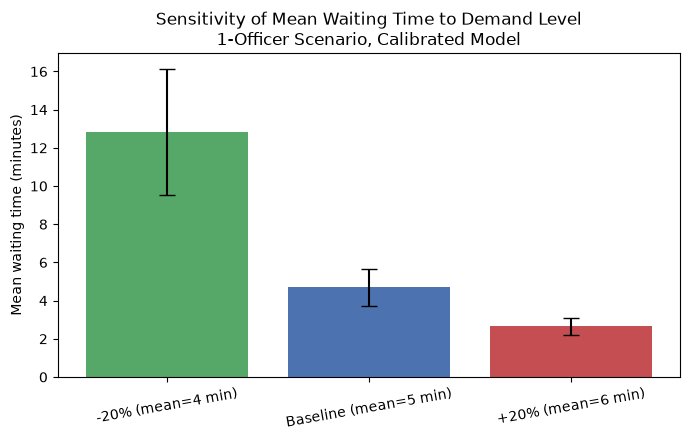

In [69]:
import matplotlib.pyplot as plt

labels = list(sensitivity_results.keys())
means = [sensitivity_results[l][0] for l in labels]
lower_errors = [sensitivity_results[l][0] - sensitivity_results[l][1] for l in labels]
upper_errors = [sensitivity_results[l][2] - sensitivity_results[l][0] for l in labels]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(labels, means, yerr=[lower_errors, upper_errors], capsize=6,
       color=["#55A868", "#4C72B0", "#C44E52"])
ax.set_ylabel("Mean waiting time (minutes)")
ax.set_title("Sensitivity of Mean Waiting Time to Demand Level\n1-Officer Scenario, Calibrated Model")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("sensitivity_analysis.png", dpi=110)
plt.show()

In [101]:
with open("part_f_sensitivity_analysis.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Demand Level", "Mean Waiting Time", "95% CI Lower", "95% CI Upper"])
    for label, (mean_wait, ci_lower, ci_upper) in sensitivity_results.items():
        writer.writerow([label, mean_wait, ci_lower, ci_upper])

print("Saved: part_f_sensitivity_analysis.csv")

Saved: part_f_sensitivity_analysis.csv
